In [ ]:
# Local scipy.stats.norm and mibian.BS fallbacks for script-style validation.
# This cell is added only to the validated composite notebook.
try:
    from scipy.stats import norm as _norm_check
except Exception:
    import math
    import sys
    import types
    import numpy as _np

    class _Norm:
        @staticmethod
        def cdf(x):
            arr = _np.asarray(x, dtype=float)
            out = 0.5 * (1.0 + _np.vectorize(math.erf)(arr / math.sqrt(2.0)))
            return float(out) if out.shape == () else out
        @staticmethod
        def pdf(x):
            arr = _np.asarray(x, dtype=float)
            out = _np.exp(-0.5 * arr * arr) / math.sqrt(2.0 * math.pi)
            return float(out) if out.shape == () else out

    scipy = types.ModuleType("scipy")
    stats = types.ModuleType("scipy.stats")
    stats.norm = _Norm()
    scipy.stats = stats
    sys.modules["scipy"] = scipy
    sys.modules["scipy.stats"] = stats

try:
    import mibian as _mibian_check
except Exception:
    import math
    import sys
    import types
    from scipy.stats import norm

    class BS:
        def __init__(self, args, volatility=None):
            self.underlyingPrice, self.strikePrice, self.interestRate, self.daysToExpiration = [float(x) for x in args]
            self.volatility = float(volatility)
            self.callPrice, self.putPrice = self._prices()
        def _prices(self):
            S = self.underlyingPrice
            K = self.strikePrice
            r = self.interestRate / 100.0
            T = self.daysToExpiration / 365.0
            sigma = self.volatility / 100.0
            if T <= 0 or sigma <= 0:
                return max(S - K, 0.0), max(K - S, 0.0)
            d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
            d2 = d1 - sigma * math.sqrt(T)
            call = S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
            put = K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
            return call, put

    mibian = types.ModuleType("mibian")
    mibian.BS = BS
    sys.modules["mibian"] = mibian
    print("Installed local scipy.stats.norm and mibian.BS fallbacks.")


# Week 17-2 · OTS-03 — Options Pricing Models & the Greeks
### Practice notebook · built on the **real lecture resources** (in-class `mibian` notebook + lecture notes)

**Faculty:** Varun Kumar Pothula (QuantInsti) · **Subject:** Options Trading & Strategies

This notebook reproduces the lecture end-to-end. **Section 1 runs the actual in-class notebook shipped with
OTS-03** — `OTS_3_code_Options Pricing Using the Black Scholes Model_.ipynb` — using the exact package the
faculty used, **`mibian`**. Sections 2–6 then unpack the same maths from scratch with `scipy` so every Greek
and no-arbitrage relationship in the cheat sheet is verified live.

| Section | Source | Key result |
|---|---|---|
| 1 | **shipped in-class notebook** (`mibian`) | call **1.566**, put **6.566** |
| 2 | lecture notes — BSM closed form | scipy matches mibian to 3 dp |
| 3 | lecture notes — put-call parity | C − P = **−5.0** = S − X·e^(−rT) |
| 4 | lecture notes — model-independent features | lower-strike call dearer; C < S; P < X |
| 5 | lecture notes — the Greeks | delta/gamma/theta/vega/rho + 4-panel chart |
| 6 | lecture notes — Greek additivity | book Greeks sum across legs |


## 0 · Setup
`mibian` is the exact library used in the shipped notebook; `scipy.stats.norm` gives us the cumulative normal N(·) for the from-scratch checks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import mibian
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('mibian', mibian.__name__, '| ready')

mibian mibian | ready


---
## 1 · The shipped in-class notebook — pricing with `mibian`
This is the faculty's own code, verbatim. `mibian.BS([S, K, r, T_days], volatility=σ)` takes the interest rate
as a **percent** and time as **days**. The worked example: a 30-day 105-strike option on a 100 stock at 30% vol.

In [2]:
# --- verbatim from OTS-03 in-class notebook ---
from mibian import BS

def calculate_option_prices(stock_price, strike_price, interest_rate, days_to_expiration, volatility, option_type):
    option = BS([stock_price, strike_price, interest_rate, days_to_expiration], volatility=volatility)
    if option_type.lower() == 'call':
        price = option.callPrice
    elif option_type.lower() == 'put':
        price = option.putPrice
    else:
        raise ValueError("Invalid option type. Use 'call' or 'put'.")
    return round(price, 3)

In [3]:
# Example usage — the exact lecture inputs
stock_price        = 100.0
strike_price       = 105.0
interest_rate      = 0
days_to_expiration = 30
volatility         = 30      # percent
call_price = calculate_option_prices(stock_price, strike_price, interest_rate, days_to_expiration, volatility, 'call')
put_price  = calculate_option_prices(stock_price, strike_price, interest_rate, days_to_expiration, volatility, 'put')
print(f"Call Option Price: {call_price}")
print(f"Put  Option Price: {put_price}")

Call Option Price: 1.566
Put  Option Price: 6.566


The 105-strike call is **out-of-the-money** (spot 100 < strike 105) so it is cheap — **1.566**. The matching put is
**in-the-money**, hence dearer — **6.566**. These are the exact figures printed in the shipped notebook.

---
## 2 · Black-Scholes from scratch — the closed form the exchanges use
$$C = S\,N(d_1) - X e^{-rT} N(d_2), \qquad d_1 = \frac{\ln(S/X) + (r + \sigma^2/2)T}{\sigma\sqrt T}, \quad d_2 = d_1 - \sigma\sqrt T$$
`N(d1)` is the **delta / hedge ratio**; `N(d2)` is the **risk-neutral probability of finishing in-the-money**.
Re-deriving the mibian numbers confirms our understanding.

In [4]:
def bsm(S, K, r_pct, T_days, vol_pct, kind='call'):
    r, sigma, T = r_pct/100, vol_pct/100, T_days/365
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if kind == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    return price, d1, d2

c, d1, d2 = bsm(100, 105, 0, 30, 30, 'call')
p, _, _   = bsm(100, 105, 0, 30, 30, 'put')
print(f"scipy  call = {c:.3f}   put = {p:.3f}")
print(f"mibian call = {call_price}   put = {put_price}   -> match")
print(f"d1 = {d1:.4f}   d2 = {d2:.4f}")
print(f"N(d1) = {norm.cdf(d1):.4f}  (delta / hedge ratio)")
print(f"N(d2) = {norm.cdf(d2):.4f}  (risk-neutral P of finishing ITM)")

scipy  call = 1.566   put = 6.566
mibian call = 1.566   put = 6.566   -> match
d1 = -0.5243   d2 = -0.6103
N(d1) = 0.3000  (delta / hedge ratio)
N(d2) = 0.2708  (risk-neutral P of finishing ITM)


### Which inputs move the premium?
BSM has **six** inputs (S, X, r, dividends, T, σ) but **no drift/return** term — parity forbids it (a positive drift
would raise *both* calls and puts, a contradiction). Bumping each input on an ATM 3-month base case (S=X=100,
r=5%, σ=20%, T=0.25, base call **4.61**) shows the direction and size of each sensitivity.

In [5]:
base = calculate_option_prices(100, 100, 5, 91, 20, 'call')   # ~3 months
bumps = {
    'base (ATM 3mo)':      calculate_option_prices(100, 100, 5, 91, 20, 'call'),
    'S  100 -> 105':       calculate_option_prices(105, 100, 5, 91, 20, 'call'),
    'sigma 20 -> 30%':     calculate_option_prices(100, 100, 5, 91, 30, 'call'),
    'T  0.25 -> 0.50':     calculate_option_prices(100, 100, 5, 182, 20, 'call'),
    'r  5 -> 8%':          calculate_option_prices(100, 100, 8, 91, 20, 'call'),
}
for k, v in bumps.items():
    print(f"  {k:<18}: {v:.2f}")

  base (ATM 3mo)    : 4.61
  S  100 -> 105     : 7.92
  sigma 20 -> 30%   : 6.57
  T  0.25 -> 0.50   : 6.88
  r  5 -> 8%        : 5.01


---
## 3 · Put-call parity — the backbone identity
$$C - P = S - X e^{-rT}$$
A portfolio of **long put + short call + long stock** is worth exactly **X** at expiry, whether the market finishes
above or below the strike. That risk-free payoff forces the parity — otherwise there is an arbitrage. It is also the
reason a call and put on the same strike are "the same thing" up to a bond, and the precursor to volatility trading.

In [6]:
lhs = call_price - put_price
rhs = stock_price - strike_price*np.exp(-(interest_rate/100)*(days_to_expiration/365))
print(f"C - P            = {lhs:.4f}")
print(f"S - X e^(-rT)    = {rhs:.4f}")
print(f"parity holds: {np.isclose(lhs, rhs, atol=1e-3)}")

# the portfolio proof: long put + short call + long stock  ->  X at expiry
for S_T in [80, 105, 130]:
    call_exp = max(S_T - strike_price, 0)
    put_exp  = max(strike_price - S_T, 0)
    portfolio = put_exp - call_exp + S_T          # long put, short call, long stock
    print(f"  S_T={S_T:>3}:  put {put_exp:>4} - call {call_exp:>4} + stock {S_T:>3}  =  {portfolio:.0f}  (= strike {strike_price:.0f})")

C - P            = -5.0000
S - X e^(-rT)    = -5.0000
parity holds: True
  S_T= 80:  put 25.0 - call    0 + stock  80  =  105  (= strike 105)
  S_T=105:  put  0.0 - call  0.0 + stock 105  =  105  (= strike 105)
  S_T=130:  put    0 - call 25.0 + stock 130  =  105  (= strike 105)


The three scenarios all settle to **105 = the strike** — the portfolio is riskless, which is what pins the parity.
Note it only holds for **European** options (American early-exercise breaks the fixed-T assumption).

---
## 4 · Model-independent (no-arbitrage) features
These hold *regardless* of the pricing model — violate them and there is free money. We confirm the two most
quantitative ones on a BSM price curve: **a lower-strike call is always dearer**, and **C < S** while **P < X**.

In [7]:
S0, r, T, vol = 100, 0, 30, 30
strikes = [90, 95, 100, 105, 110]
rows = []
for K in strikes:
    c, _, _ = bsm(S0, K, r, T, vol, 'call')
    p, _, _ = bsm(S0, K, r, T, vol, 'put')
    rows.append({'strike': K, 'call': round(c,3), 'put': round(p,3)})
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
print()
print('lower-strike call dearer :', bool((tbl.call.diff().dropna() < 0).all()))
print('every call < spot (100)  :', bool((tbl.call < S0).all()))
print('every put  < strike      :', bool((tbl.put < tbl.strike).all()))

 strike   call    put
     90 10.434  0.434
     95  6.422  1.422
    100  3.430  3.430
    105  1.566  6.566
    110  0.609 10.609

lower-strike call dearer : True
every call < spot (100)  : True
every put  < strike      : True


---
## 5 · The Greeks — the dials a trader actually watches
The Greeks are the partial derivatives of the option price. We use an illustrative ATM base case
**S = X = 100, r = 5%, σ = 20%, T = 3 months** (the standard textbook set) so the shapes are clean.

| Greek | measures | formula (call) |
|---|---|---|
| Delta | ∂C/∂S | N(d₁) |
| Gamma | ∂²C/∂S² | N′(d₁)/(S·σ·√T) |
| Theta | ∂C/∂t | time decay (per day) |
| Vega | ∂C/∂σ | S·N′(d₁)·√T (per 1% vol) |
| Rho | ∂C/∂r | X·T·e^(−rT)·N(d₂) (per 1% rate) |

In [8]:
def greeks(S, K, r, T, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100                 # per 1% vol
    theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T))
             - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365          # per day
    rho   = K*T*np.exp(-r*T)*norm.cdf(d2) / 100              # per 1% rate
    return delta, gamma, theta, vega, rho

S, K, r, T, sigma = 100, 100, 0.05, 0.25, 0.20
delta, gamma, theta, vega, rho = greeks(S, K, r, T, sigma)
print(f"ATM call (S=X=100, r=5%, sigma=20%, T=0.25):")
print(f"  Delta = {delta:+.4f}   (hedge ratio; call-put delta = 1)")
print(f"  Gamma = {gamma:+.4f}   (peaks ATM & near expiry)")
print(f"  Theta = {theta:+.4f}   (decay per day)")
print(f"  Vega  = {vega:+.4f}   (per +1% vol; peaks ATM, bigger long-dated)")
print(f"  Rho   = {rho:+.4f}   (per +1% rate; minor)")

ATM call (S=X=100, r=5%, sigma=20%, T=0.25):
  Delta = +0.5695   (hedge ratio; call-put delta = 1)
  Gamma = +0.0393   (peaks ATM & near expiry)
  Theta = -0.0287   (decay per day)
  Vega  = +0.1964   (per +1% vol; peaks ATM, bigger long-dated)
  Rho   = +0.1308   (per +1% rate; minor)


In [9]:
# Gamma peaks ATM: check across strikes
for K in [90, 100, 110]:
    _, g, _, _, _ = greeks(100, K, 0.05, 0.25, 0.20)
    tag = '  <- peak (ATM)' if K == 100 else ''
    print(f"  strike {K}: gamma = {g:.4f}{tag}")
print()
# Vega grows with time to expiry
for label, t in [('1 week', 7/365), ('3 months', 0.25), ('1 year', 1.0)]:
    _, _, _, v, _ = greeks(100, 100, 0.05, t, 0.20)
    print(f"  vega {label:>9}: {v:.4f}")

  strike 90: gamma = 0.0188
  strike 100: gamma = 0.0393  <- peak (ATM)
  strike 110: gamma = 0.0295

  vega    1 week: 0.0552
  vega  3 months: 0.1964
  vega    1 year: 0.3752


### The four pictures — payoff, delta, gamma, vega
One figure for the cheat sheet.

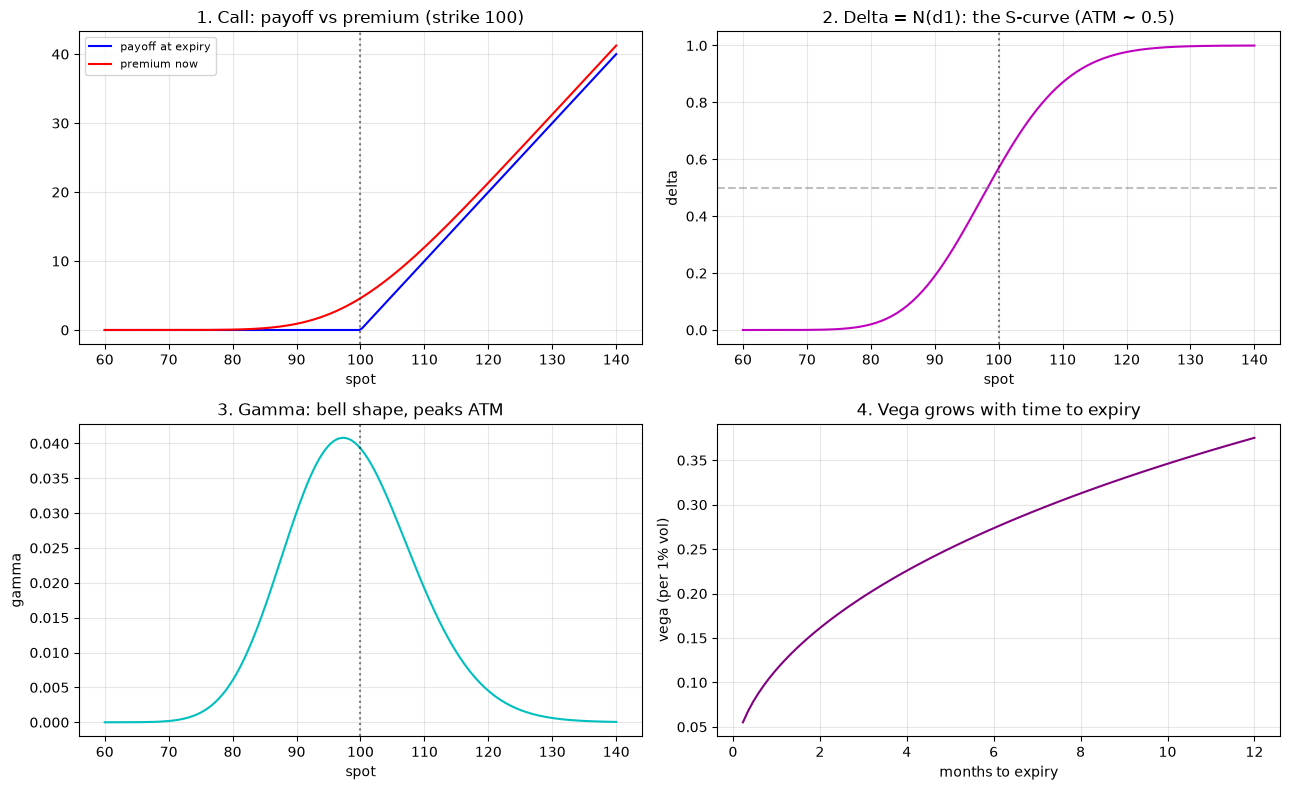

saved chart_1_greeks.png


In [10]:
S_grid = np.linspace(60, 140, 200)
call_prem = np.array([bsm(s, 100, 5, 91.25, 20, 'call')[0] for s in S_grid])
deltas    = np.array([greeks(s, 100, 0.05, 0.25, 0.20)[0] for s in S_grid])
gammas    = np.array([greeks(s, 100, 0.05, 0.25, 0.20)[1] for s in S_grid])
times     = np.linspace(7/365, 1.0, 100)
vegas     = np.array([greeks(100, 100, 0.05, t, 0.20)[3] for t in times])

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
# payoff vs premium
ax[0,0].plot(S_grid, np.maximum(S_grid-100, 0), 'b-', label='payoff at expiry')
ax[0,0].plot(S_grid, call_prem, 'r-', label='premium now')
ax[0,0].axvline(100, color='k', ls=':', alpha=.5); ax[0,0].set_title('1. Call: payoff vs premium (strike 100)')
ax[0,0].set_xlabel('spot'); ax[0,0].legend(fontsize=8)
# delta S-curve
ax[0,1].plot(S_grid, deltas, 'm-'); ax[0,1].axvline(100, color='k', ls=':', alpha=.5)
ax[0,1].axhline(0.5, color='gray', ls='--', alpha=.5)
ax[0,1].set_title('2. Delta = N(d1): the S-curve (ATM ~ 0.5)'); ax[0,1].set_xlabel('spot'); ax[0,1].set_ylabel('delta')
# gamma bell
ax[1,0].plot(S_grid, gammas, 'c-'); ax[1,0].axvline(100, color='k', ls=':', alpha=.5)
ax[1,0].set_title('3. Gamma: bell shape, peaks ATM'); ax[1,0].set_xlabel('spot'); ax[1,0].set_ylabel('gamma')
# vega vs time
ax[1,1].plot(times*12, vegas, color='purple'); ax[1,1].set_title('4. Vega grows with time to expiry')
ax[1,1].set_xlabel('months to expiry'); ax[1,1].set_ylabel('vega (per 1% vol)')

plt.tight_layout()
plt.savefig('chart_1_greeks.png', dpi=110, bbox_inches='tight', facecolor='white')
plt.show()
print('saved chart_1_greeks.png')

---
## 6 · Greeks are additive across a book
Because the BSM equation is linear, a portfolio's Greeks are just the **sum** of each leg's Greeks (× position ×
contract size). A trader says "I'm long 5000 delta, short 500 theta, long 1000 vega." Example book: long 10 ATM
calls, short 5 of the 110-strike calls (×100 multiplier).

In [11]:
mult = 100
# leg 1: long 10 ATM (strike 100) calls
d1g = greeks(100, 100, 0.05, 0.25, 0.20)
# leg 2: short 5 of the 110 calls
d2g = greeks(100, 110, 0.05, 0.25, 0.20)
pos1, pos2 = 10, -5

net = {}
for i, name in enumerate(['delta','gamma','theta','vega','rho']):
    net[name] = (pos1*d1g[i] + pos2*d2g[i]) * mult

print("Net book Greeks (long 10x100 ATM calls, short 5x100 110-calls):")
print(f"  net delta = {net['delta']:+.1f}   -> ${net['delta']:+.0f} per $1 up-move")
print(f"  net theta = {net['theta']:+.1f}   -> ${net['theta']:+.0f} per day decay")
print(f"  net vega  = {net['vega']:+.1f}   -> ${net['vega']:+.0f} per +1% vol")

Net book Greeks (long 10x100 ATM calls, short 5x100 110-calls):
  net delta = +460.3   -> $+460 per $1 up-move
  net theta = -19.2   -> $-19 per day decay
  net vega  = +122.8   -> $+123 per +1% vol


---
### Recap — what OTS-03 established
- **Premium = intrinsic + time value.** A 105-call on a 100 stock (30d, 30% vol) is worth **1.566**; the 105-put **6.566**.
- **Black-Scholes** turns six inputs (S, X, r, dividends, T, σ) into a fair price — **no drift/return** term, because of parity.
  `N(d1)` is the delta/hedge ratio; `N(d2)` the risk-neutral P(ITM). scipy reproduces mibian to 3 dp.
- **Put-call parity** `C − P = S − X e^(−rT)` (= −5 here) is the backbone identity and the precursor to volatility trading.
- **Model-independent** no-arb features (lower-strike call dearer, C < S, P < X, American > European) must hold or there is free money.
- **The Greeks** are the price's partial derivatives — delta (S-curve), gamma (bell, peaks ATM), theta (decay), vega
  (peaks ATM, grows with expiry), rho (minor). They **sum across a book**, which is how traders quote and hedge risk.
- BSM prices **European** options only; American options need numerical methods (binomial trees).


---

# Additive source-backed continuation

The original notebook cells above are preserved. The first added cell supplies local scipy/mibian fallbacks for validation only.


# OTS-03 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for Black-Scholes pricing, Greeks, put-call parity, and model limits.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['ots03_source_pdf_inventory.csv','ots03_source_zip_inventory.csv','ots03_option_pricing_reference.csv','ots03_black_scholes_input_sensitivity.csv','ots03_greeks_reference.csv','ots03_parity_arbitrage_check.csv','ots03_model_assumption_controls.csv','ots03_portfolio_greeks.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Source and dependency inventory

The source zip contains the in-class Black-Scholes notebook. The local environment is missing scipy and mibian, so the validated composite notebook adds local fallbacks.

In [ ]:
print(data['ots03_source_pdf_inventory.csv'][['file','pages','keyword_hits']].to_string(index=False))
print(data['ots03_source_zip_inventory.csv'].to_string(index=False))
assert data['ots03_source_zip_inventory.csv']['role'].str.contains('notebook').any()

## 2. Black-Scholes and parity checks

The lecture example prices a 30-day 105-strike option on spot 100 with 30% volatility and zero rate.

In [ ]:
pricing = data['ots03_option_pricing_reference.csv']
parity = data['ots03_parity_arbitrage_check.csv']
print(pricing.head(7).to_string(index=False))
print(parity.to_string(index=False))
assert pricing['case'].str.contains('lecture_call').any()
assert parity['scenario'].str.contains('american_precision').any()

## 3. Greeks, assumptions, and portfolio additivity

Greeks are local sensitivities; they add across legs only after position size and contract multiplier are applied.

In [ ]:
greeks = data['ots03_greeks_reference.csv']
controls = data['ots03_model_assumption_controls.csv']
portfolio = data['ots03_portfolio_greeks.csv']
print(greeks.to_string(index=False))
print(controls.to_string(index=False))
print(portfolio.to_string(index=False))
assert controls['topic'].str.contains('American').any()
assert portfolio['greek'].str.contains('delta').any()